# Mapping Kafka and Lispector with Machine Learning: Where do Kafka and Lispector think alike?

This notebook walks through the whole analysis, one step at a time. Each step has a short plain-language explanation, the real code from `src/`, and its output.

**The question.** Franz Kafka and Clarice Lispector wrote in different languages, decades and countries. Are there passages in their books that are about the *same thing*, even though the words and the style differ?

**TLDR:**
1. Cut ten books into short passages.
2. Turn every passage into a list of numbers that captures its meaning (an *embedding*).
3. The numbers also capture *who wrote it*, which would drown out everything else. So the author signal is mathematically removed.
4. Pair up the closest cross-author passages (*bridges*), draw a map, and test whether the result is real or an artefact.

### Words used below

| Term | Meaning |
|---|---|
| **Passage** | A paragraph-sized piece of a book, 70 to 280 words. The unit of analysis. |
| **Embedding** | A passage turned into a list of numbers (a *vector*). Passages with similar meaning get similar numbers, like nearby points on a map. |
| **Cosine similarity** | How close two vectors point in the same direction. 1 means the same, 0 means unrelated. |
| **Reading** | One way of embedding: a model plus an instruction telling it what to pay attention to. |
| **Probe** | A simple classifie trained to guess the author from a vector. If it succeeds, the author is still 'in' the numbers. |

In [ ]:
import inspect
import json
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Code, display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from src.core import config
from src.core.common import bridges, csls, emb, load, mixing, neighbours, read

KAFKA, LISPECTOR = '#1b6ca8', '#d9822b'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})


def show_code(*fns):
    display(Code('\n\n'.join(inspect.getsource(f) for f in fns), language='python'))


def wrap(text, n=110):
    return textwrap.fill(text, n)


rows, y = load()
print(f'{len(rows)} passages loaded ({int(y.sum())} Kafka, {int((1 - y).sum())} Lispector)')

5324 passages loaded (2309 Kafka, 3015 Lispector)


## 1. The corpus

Ten English-language books, five per author. Everything about them (titles, where each work starts and ends) is in one settings file, `src/core/config.py`.

In [2]:
counts = {}
for r in rows:
    counts[r['book']] = counts.get(r['book'], 0) + 1
print(f"{'author':10s} {'year':5s} {'passages':>8s}  title")
for meta in config.BOOKS.values():
    print(f"{meta['author']:10s} {meta['year']:<5d} {counts[meta['key']]:8d}  {meta['title']}")

author     year  passages  title
Lispector  1973       206  Água Viva
Kafka      1927       563  Amerika
Kafka      1918        65  Aphorisms
Kafka      1924       973  The Complete Stories
Lispector  1977      1451  The Complete Stories
Kafka      1915       123  The Metamorphosis
Kafka      1923       585  Letters to Milena
Lispector  1964       417  The Passion According to G.H.
Lispector  1977       204  The Hour of the Star
Lispector  1973       737  Too Much of Life (crônicas)


## 2. Cleaning (`src/prep/clean.py`)

The books start as EPUB files converted to plain text. That text still has tables of contents, page images, editorial notes in `[brackets]` and front matter. Cleaning cuts to the first line of the actual work and deletes those pieces, so the model only reads the author's words.


In [3]:
from src.prep import clean

sample = 'He looked out. [image: cover.jpg] The rain fell [Translator: sic] all night.\n\n\n\nMorning came.'
for pattern, repl in clean.PATTERNS:
    sample = pattern.sub(repl, sample)
print(sample)

print()
print('saved: bracketed spans removed per book')
report = read('clean_report.json')
for num, meta in config.BOOKS.items():
    print(f"  {meta['title'][:32]:32s} {report[num]['brackets_removed']:4d}")

He looked out.  The rain fell  all night.

Morning came.

saved: bracketed spans removed per book
  Água Viva                           2
  Amerika                             0
  Aphorisms                           3
  The Complete Stories               10
  The Complete Stories                2
  The Metamorphosis                   1
  Letters to Milena                 163
  The Passion According to G.H.       2
  The Hour of the Star                4
  Too Much of Life (crônicas)        13


## 3. Chunking (`src/prep/chunk.py`)

A model reads a few hundred words at a time, and meaning is easier to compare at paragraph size. The chunker keeps paragraph boundaries: short paragraphs are merged forward until they reach 70 words, long ones are split at sentence ends before 280 words, and scraps under 35 words are dropped.

A couple of things to keep in mind for later:
- Every passage gets a unique ID generated from a hash of its text. Cache entries are filed by this ID, so updating one chunk won't touch the others.

- Kafka's The Complete Stories happens to contain an extra English translation of The Metamorphosis. That duplicate is set aside as the "twins" set and used only for the translation check in section 11.


MIN_WORDS=70, MAX_WORDS=280, DROP_BELOW=35
501 text lines -> 204 passages, 0 scraps dropped

Yes, but don’t forget that to write anything at all my basic material is the word. So that’s why this story
will be made of words that gather in sentences and from these a secret meaning emanates that goes beyond words
and sentences. Naturally, like every writer I’m tempted to use succulent terms: I know splendid adjectives,
meaty nouns, and verbs so slender that they travel sharp through the air about to go into action, since words
are actions, don’t you agree? I’m not going to adorn the word because if I touch the girl’s bread the bread
will turn to gold — and the girl (she’s nineteen) the girl wouldn’t be able to bite it, dying of hunger. So I
have to speak simply to capture her delicate and vague existence. I humbly limit myself — without trumpeting
my humility for then it wouldn’t be humble — I limit myself to telling of the lame adventures of a girl in a
city that’s entirely against her. 

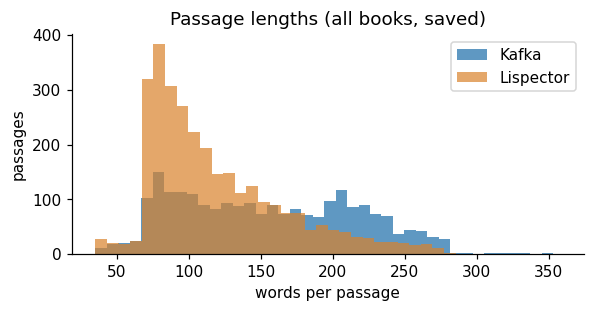

In [4]:
from src.prep import chunk

print(f'MIN_WORDS={config.MIN_WORDS}, MAX_WORDS={config.MAX_WORDS}, DROP_BELOW={config.DROP_BELOW}')
lines = chunk.book_lines('9', config.BOOKS['9'])
units, dropped = chunk.passages(lines, 'hour')
print(f'{len(lines)} text lines -> {len(units)} passages, {len(dropped)} scraps dropped\n')
print(wrap(units[10]['text']))

words = {a: [r['words'] for r in rows if r['author'] == a] for a in ('Kafka', 'Lispector')}
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.hist(words['Kafka'], bins=40, alpha=.7, color=KAFKA, label='Kafka')
ax.hist(words['Lispector'], bins=40, alpha=.7, color=LISPECTOR, label='Lispector')
ax.set(xlabel='words per passage', ylabel='passages', title='Passage lengths (all books, saved)')
ax.legend()
plt.show()

Kafka's passages run longer on average. That is a trap the notebook will check for later: if length alone could tell the authors apart, a 'similar meaning' match might really be a 'similar length' match.

## 4. Embeddings (`src/embedding/embed.py`)

An **embedding model** is a neural network trained on huge amounts of text to place sentences with similar meaning close together. It reads a passage and outputs a list of numbers (768 or 1024 of them).  The numbers are never looked at directly. The script only compares them: two passages whose vectors point the same way are *about the same kind of thing*.



In [5]:
from src.embedding import embed

sentences = [
    'The old man could not sleep, and lay listening to the rain.',
    'Awake all night, he heard the water falling on the roof.',
    'The bank raised its interest rates again this quarter.',
    'Nobody had told her the train would leave early.',
]
model = embed.encoder('mpnet')
V = model.encode(sentences, normalize_embeddings=True)
print('vector length:', V.shape[1])
sim = V @ V.T
print('\ncosine similarity (1 = same meaning):')
for i, s in enumerate(sentences):
    print(' ', ' '.join(f'{v:5.2f}' for v in sim[i]), ' ', s[:45])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

vector length: 768

cosine similarity (1 = same meaning):
   1.00  0.49 -0.03  0.03   The old man could not sleep, and lay listenin
   0.49  1.00  0.11  0.05   Awake all night, he heard the water falling o
  -0.03  0.11  1.00  0.02   The bank raised its interest rates again this
   0.03  0.05  0.02  1.00   Nobody had told her the train would leave ear


Sentences 1 and 2 share no words but score 0.49, while every other pair sits near 0. That is the whole idea.

### Four readings

The project compares four *readings*. The larger Qwen3 model accepts an **instruction** in front of the text, so I can tell it what to focus on. The instruction is the parameter that pushes the model towards themes (existence, guilt, isolation) and away from plot and setting.

| Reading | Model | Instruction |
|---|---|---|
| `mpnet` | all-mpnet-base-v2 | none |
| `qwen` | Qwen3-Embedding-0.6B | none |
| `qwen-neutral` | Qwen3-Embedding-0.6B | 'Identify the theme of this literary passage' |
| `qwen-theme` | Qwen3-Embedding-0.6B | existential theme, ignoring plot, characters, setting, style |

Having `qwen` and `qwen-neutral` next to `qwen-theme` separates two effects: changing the model, and adding the instruction. The `qwen-theme` reading is the one the map uses.

The Qwen encoder is long to run, so here is only its code and its prompts (*not run*).

In [6]:
show_code(embed.encoder, embed.run)
print(config.THEME)
print(config.NEUTRAL)

def encoder(reading):
    import torch
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(8)
    m = MODELS[READINGS[reading]["model"]]
    model = SentenceTransformer(m["name"], revision=m["revision"], device="cpu")
    model.max_seq_length = m["max_len"]
    return model


def run(reading):
    rows, twins = read("passages.json"), read("twins.json")
    texts = {r["uid"]: r["text"] for r in rows + twins}
    have = load_cache(reading)
    todo = [u for u in texts if u not in have]
    print(f"{reading}: {len(texts) - len(todo)} cached, {len(todo)} to encode", flush=True)
    if todo:
        model, t = encoder(reading), time.time()
        for k in range(0, len(todo), SHARD):
            batch = todo[k:k + SHARD]
            vec = model.encode([texts[u] for u in batch], batch_size=16, prompt=READINGS[reading]["prompt"],
                               normalize_embeddings=True, show_progress_bar=False, convert_to_numpy=True)
            have.update(zip(batch, vec.astype(np.float32)))
            save_cache(reading, have)
            print(f"{reading}: {min(k + SHARD, len(todo))}/{len(todo)} at {time.time() - t:.0f} s", flush=True)
    np.save(DATA / f"emb_{reading}.npy", np.stack([have[r["uid"]] for r in rows]))
    if twins:
        np.save(DATA / f"twins_{reading}.npy", np.stack([have[r["uid"]] for r in twins]))
    print(f"{reading}: corpus {len(rows)}, twins {len(twins)}", flush=True)

Instruct: Identify the existential and philosophical theme of this literary passage, setting aside its plot, characters, setting and prose style
Query: 
Instruct: Identify the theme of this literary passage
Query: 


`run` encodes only the passages not already in the cache (`src/core/cache.py`), 256 at a time, saving after each batch so an interruption loses nothing.

## 5. The problem: the author is still in the numbers

*Saved* embeddings, live analysis. For each passage, look at its 15 nearest neighbours. If meaning alone decided, about half should be by the other author. Let us see.

In [7]:
X = emb('qwen-theme')
nb = neighbours(X)
same = (y[nb] == y[:, None]).mean()
print(f'{same:.0%} of a passage\'s 15 nearest neighbours are by the same author (chance would be about 50%)')

i = int(np.where(y == 1)[0][400])
print(f"\nA Kafka passage ({rows[i]['title']}):\n")
print(wrap(rows[i]['text'][:400]) + ' ...')
print('\nIts three nearest neighbours:')
S = X @ X[i]
for j in np.argsort(-S)[1:4]:
    print(f"\n  [{rows[j]['author']}, {rows[j]['title']}, cosine {S[j]:.2f}]")
    print('  ' + wrap(rows[j]['text'][:250], 100).replace('\n', '\n  ') + ' ...')

82% of a passage's 15 nearest neighbours are by the same author (chance would be about 50%)

A Kafka passage (Amerika):

“Why can’t we go in?” “We’re not allowed in until the bell rings,” said Robinson, and he devoured the greasy
bread with his mouth, which he had opened as wide as possible, using one hand to catch the oil dripping from
the bread so that now and then he could dip the rest of the bread into the palm of his hand, which served as a
reservoir. “Everything has become stricter. At first there was only a t ...

Its three nearest neighbours:

  [Kafka, Amerika, cosine 0.85]
  “Well, I certainly know more about that than you do,” said Robinson, wiping his eyes with the tip of
  his blanket. “The student in the apartment next door, which belongs to the landlady, who also cooks
  for us, told me last time as I was returning the ...

  [Kafka, Amerika, cosine 0.84]
  At last Robinson could be seen on a landing before a closed apartment door, and now they had
  arrived; the stairca

The model is picking up **voice**: sentence rhythm, translator habits, vocabulary. A simple *probe* can guess the author from the raw numbers about 93% of the time. Any 'similar meaning' between authors would be hidden behind this. So it is removed.

## 6. Erasing the author (`src/erasure/erase.py`)

Two steps, both standard statistical operations on the cloud of vectors:

1. **LEACE** finds the one direction in the space that best separates Kafka from Lispector, and flattens it out, so that *no linear classifier* can use the author's average position any more.
2. **CORAL** then matches the *spread* of the two authors' clouds (how wide and in which directions each one varies), after shrinking to 256 dimensions. Kafka's cloud is shaped differently from Lispector's, and shape alone still betrays the author.

**LEACE**

$$x_{\text{LEACE}} = x - P(x - \mu)$$

$$P = \Sigma^{1/2} P_{\text{author}} \, \Sigma^{-1/2}$$

LEACE replaces each vector x by x - P(x - mean), where P projects onto the directions along which the author label is linearly predictable, in whitened coordinates.

**CORAL**

$$x_{\text{CORAL}} = \Sigma_{\text{pooled}}^{1/2} \Sigma_a^{-1/2} (x - \mu_a) + \mu_a$$


 CORAL whitens each author's covariance and recolours it with the pooled covariance.

In [8]:
from src.erasure import erase

show_code(erase.leace, erase.fit_eraser)

def leace(X, z, eps=1e-6):
    """Fit the LEACE eraser for concept labels z (n, k one-hot or n binary); returns x -> erased x."""
    Z = z.reshape(len(z), -1).astype(np.float64)
    mu = X.mean(0)
    Xc = X - mu
    Zc = Z - Z.mean(0)
    cov = Xc.T @ Xc / len(X)
    L, V = np.linalg.eigh(cov)
    keep = L > eps * L.max()
    W = (V[:, keep] / np.sqrt(L[keep])) @ V[:, keep].T
    W_pinv = (V[:, keep] * np.sqrt(L[keep])) @ V[:, keep].T
    U, s, _ = np.linalg.svd(W @ (Xc.T @ Zc / len(X)), full_matrices=False)
    U = U[:, s > eps * max(s.max(), eps)]
    edit = W_pinv @ (U @ U.T) @ W

    def apply(A):
        return A - (A - mu) @ edit.T

    return apply


def fit_eraser(X, y, idx=None, stage="moments", dims=CORAL_DIMS, concept=None):
    """Fit on X[idx] (default: every passage); returns (A, author labels) -> erased A.

    stage is "leace", "pca" (LEACE then truncation only) or "moments" (LEACE then CORAL); concept overrides the author for LEACE.
    """
    idx = np.arange(len(y)) if idx is None else idx
    z = y if concept is None else concept
    lea = leace(X[idx], z[idx])
    if stage == "leace":
        return lambda A, labels: lea(A)
    Xl = lea(X)
    if stage == "pca":
        mu, P, _ = principal(Xl, idx, dims)
        return lambda A, labels: (lea(A) - mu) @ P
    cor, _ = fit_coral(Xl, y, idx, dims)
    return lambda A, labels: cor(lea(A), labels)

In [9]:
from src.core.common import unit

Xm = emb('mpnet')
views = {'raw': Xm}
for stage in ('leace', 'moments'):
    views[stage] = unit(erase.fit_eraser(Xm, y, stage=stage)(Xm, y))

print(f"{'stage':10s} {'dims':>5s} {'author probe':>13s} {'author mixing':>14s}")
for stage, V in views.items():
    probe = erase.probe(V, y) if stage == 'raw' else erase.probe_heldout(Xm, y, stage)
    print(f'{stage:10s} {V.shape[1]:5d} {probe:13.2f} {mixing(V, y)[0]:14.2f}')
print('\nprobe: 0.5 = author cannot be guessed.  mixing: 1 = neighbours are as author-mixed as chance.')

stage       dims  author probe  author mixing


raw          768          0.93           0.26


leace        768          0.56           0.37


moments      256          0.57           0.67

probe: 0.5 = author cannot be guessed.  mixing: 1 = neighbours are as author-mixed as chance.


The probe falls from about 0.93 to about 0.56, near a coin flip, and neighbours become far more mixed across authors. To *see* the change, project the vectors onto their two largest directions of variation (a plain PCA):

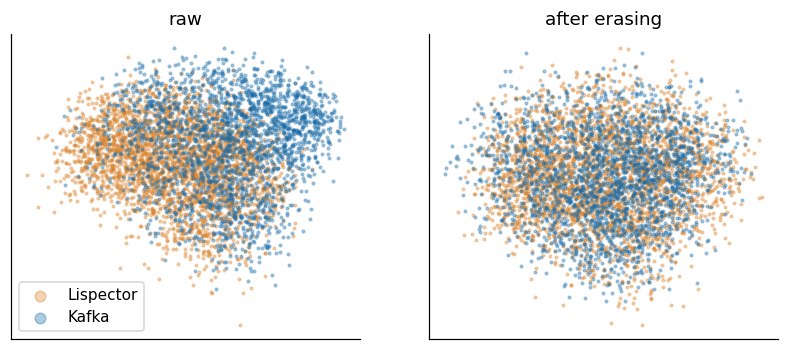

In [10]:
def pca2(V):
    V = V - V.mean(0)
    _, _, Vt = np.linalg.svd(V, full_matrices=False)
    return V @ Vt[:2].T


fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (stage, V) in zip(axes, {'raw': views['raw'], 'after erasing': views['moments']}.items()):
    P = pca2(V)
    for a, c, name in ((0, LISPECTOR, 'Lispector'), (1, KAFKA, 'Kafka')):
        ax.scatter(*P[y == a].T, s=3, alpha=.35, color=c, label=name)
    ax.set(title=stage, xticks=[], yticks=[])
axes[0].legend(markerscale=4)
plt.show()

Left: two separate clouds. Right: the same passages after erasure, overlapping. Now nearness can mean shared meaning instead of shared voice.

## 7. Bridges (`src/core/common.py`)

A **bridge** is a Kafka passage and a Lispector passage that are each other's best match. 

- **Mutual.** A passage's nearest neighbour must also pick it back.
- **CSLS scoring.** Some passages are 'hubs', vaguely close to everything. CSLS subtracts each passage's average closeness to the other author, so a hub cannot win just by being generic. The score is `2 * cos(a, b) - r(a) - r(b)`, where `r` is that average over the 10 closest cross-author passages.

**CSLS Scoring**

$$\operatorname{CSLS}(a, b) = 2 \cos(a, b) - r(a) - r(b)$$

$$r(a) = \frac{1}{K} \sum_{b' \in \mathcal{N}_B(a)} \cos(a, b')$$

where $K = 10$, and $\mathcal{N}_B(a)$ contains the 10 nearest passages by the other author.

In [11]:
show_code(csls, bridges)
Xe = emb(config.FINAL, 'erased')
found = bridges(Xe, y)
print(f'{len(found)} bridges between {int(y.sum())} Kafka and {int((1 - y).sum())} Lispector passages\n')
for b in found[:3]:
    k, l = rows[b['k']], rows[b['l']]
    print(f"--- CSLS {b['csls']:.2f}, cosine {b['cos']:.2f}")
    print(f"Kafka, {k['title']}:\n{wrap(k['text'][:380])} ...\n")
    print(f"Lispector, {l['title']}:\n{wrap(l['text'][:380])} ...\n")

def csls(X, y, k=CSLS_K):
    """Kafka rows ki, Lispector rows li, their cosines S and CSLS scores C = 2 cos - r_L(k) - r_K(l)."""
    Xn = unit(X)
    ki, li = np.where(y == 1)[0], np.where(y == 0)[0]
    S = Xn[ki] @ Xn[li].T
    rk, rl = radii(S, k)
    return ki, li, S, 2 * S - rk[:, None] - rl[None, :]


def bridges(X, y, k=CSLS_K, cosine=False):
    """Cross-author mutual best matches, strongest first, by CSLS (or plain cosine)."""
    ki, li, S, C = csls(X, y, k)
    M = S if cosine else C
    out = [dict(k=int(ki[a]), l=int(li[b]), csls=float(C[a, b]), cos=float(S[a, b])) for a, b in mutual(M)]
    out.sort(key=lambda d: -(d["cos"] if cosine else d["csls"]))
    return out

1203 bridges between 2309 Kafka and 3015 Lispector passages

--- CSLS 0.48, cosine 0.74
Kafka, Letters to Milena:
II. The possibility which is virtually magnificent thanks to the schedule: I likewise leave here at 4:12, but
am already in Gmünd by 7:28 P.M. Even if I leave with the morning express on Sunday, it’s not until 10:46, so
we have over 15 hours, some of which we could also sleep. But it gets even better. I don’t even have to take
that train; there’s a local to Prague at 4:38 in th ...

Lispector, Too Much of Life (crônicas):
Even I surprise myself when I realize how many hours a year I have to spend. I convince myself that in reality
I have more time than I think—and this means that I live more than I imagined. We just need to add up the
hours in the day, the week, the month, the year. It was an Englishman who did the calculation; I don’t know
his name. A year has 365 days—or rather, 8,760 hours. T ...

--- CSLS 0.38, cosine 0.71
Kafka, Amerika:
However, that was by no means h

## 8. The map (`src/mapping/atlas.py`)

A vector with 256 numbers cannot be drawn. **UMAP** squeezes the cloud down to two dimensions while trying to keep near passages near. Fitting UMAP on 5,000 passages is slow,the saved layout is already loaded here and only the code is shown. Passages then get grouped into 18 **constellations** with Ward clustering, a method that repeatedly merges the two most similar groups, and each constellation was named by reading its passages (`curation.json`).

In [12]:
from src.mapping import atlas

show_code(atlas.layout, atlas.constellations)
print(config.UMAP_2D)

def layout(X, seed=SEED):
    return umap.UMAP(random_state=seed, **UMAP_2D).fit_transform(X)


def constellations(X, seed=SEED):
    """Ward clusters of a 10-d UMAP, and the embedding they were cut from."""
    z10 = umap.UMAP(random_state=seed, **UMAP_10D).fit_transform(X)
    return AgglomerativeClustering(n_clusters=K_CONSTELLATIONS, linkage="ward").fit_predict(z10), z10

{'n_components': 2, 'n_neighbors': 50, 'min_dist': 0.1, 'metric': 'cosine', 'init': 'spectral'}


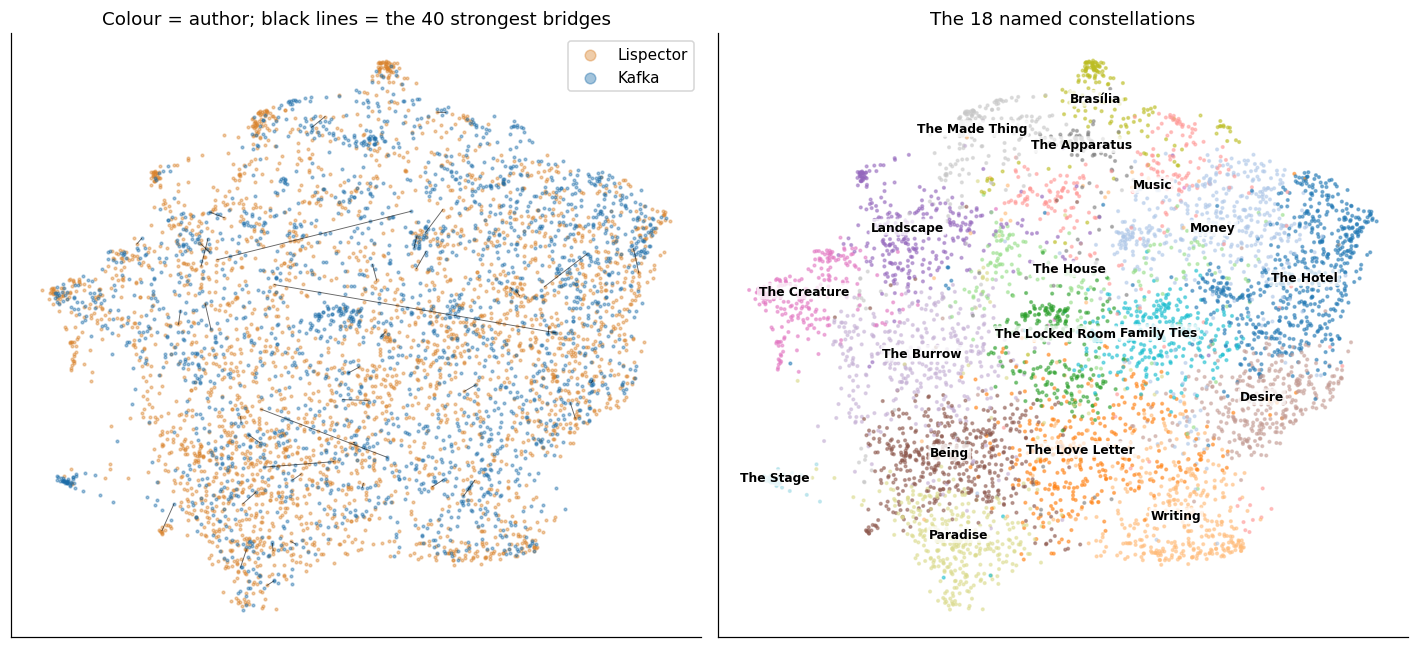

In [13]:
z = np.load(config.DATA / 'atlas.npz')
P, labels = z['final'], z['labels']
names = json.loads(config.CURATION.read_text(encoding='utf-8'))['constellations']['names']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
ax = axes[0]
for a, c, name in ((0, LISPECTOR, 'Lispector'), (1, KAFKA, 'Kafka')):
    ax.scatter(*P[y == a].T, s=3, alpha=.4, color=c, label=name)
for b in found[:40]:
    ax.plot(*P[[b['k'], b['l']]].T, color='k', lw=.6, alpha=.6)
ax.set(title='Colour = author; black lines = the 40 strongest bridges', xticks=[], yticks=[])
ax.legend(markerscale=4)

ax = axes[1]
ax.scatter(*P.T, s=3, alpha=.5, c=labels, cmap='tab20')
for c in np.unique(labels):
    m = np.median(P[labels == c], 0)
    ax.text(*m, names[str(c)], ha='center', fontsize=8, weight='bold',
            bbox=dict(boxstyle='round,pad=.15', fc='white', alpha=.75, lw=0))
ax.set(title='The 18 named constellations', xticks=[], yticks=[])
plt.tight_layout()
plt.show()

## 9. What is in each constellation? 

`kafka` is the share of Kafka passages. A value near 0.5 means the constellation is shared by both authors. Values near 0 or 1 mean it belongs to one author.

In [14]:
consts = read('constellations.json')
print(f"{'constellation':16s} {'n':>4s} {'kafka':>6s}  top words")
for c in sorted(consts, key=lambda c: c['kafka']):
    print(f"{names[str(c['id'])]:16s} {c['n']:4d} {c['kafka']:6.2f}  {', '.join(c['keywords'][:5])}")
summary = read('atlas_summary.json')
print(f"\n{summary['same_constellation']['bridges']:.0%} of bridges sit inside one constellation, against "
      f"{summary['same_constellation']['random_pairs']:.0%} for random cross-author pairs.")

constellation       n  kafka  top words
Being             468   0.28  trapeze, urca, precedes, transcending, expand
Paradise          357   0.33  doorkeeper, thou, accretion, morality, inhuman
The House         171   0.33  costume, acre, carnival, knit, gum
The Creature      251   0.35  coati, buffalo, chicken, marmoset, turtle
The Made Thing    214   0.38  harrow, symmetry, designer, officer, commandant
Family Ties       287   0.38  catarina, georg, cousin, blumfeld, dores
The Burrow        367   0.39  burrow, castle, burrowing, cockroaches, moss
Landscape         308   0.41  ulysses, puddles, litter, bridges, sports
The Love Letter   358   0.42  schubal, omit, schmar, gross, sirs
Desire            335   0.44  annie, angélica, blunder, marriage, ulein
Writing           374   0.45  atonal, marly, pamphlet, analysis, translation
The Hotel         608   0.49  schubal, waiter, carla, almira, rossmann
Music             224   0.49  fanny, piping, josephine, troupe, personnel
Brasília       

## 10. Does it hold up? Benchmarks (`src/evaluation/benchmarks.py`)

A method that finds bridges is only worth something if the bridges are not an artefact. The benchmark stage runs several checks. The first shows how much author signal each step removes, for every reading.

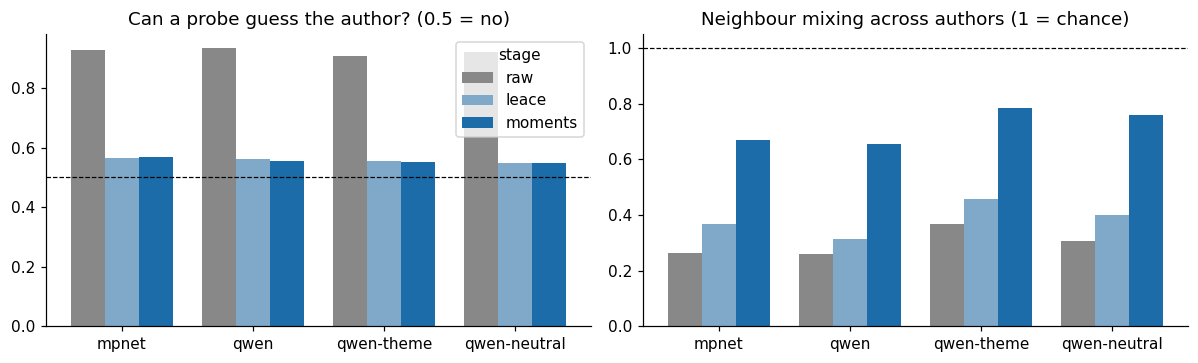

In [15]:
metrics = read('erasure_metrics.json')
readings = list(dict.fromkeys(m['embedding'] for m in metrics))
stages = ['raw', 'leace', 'moments']
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, key, title, ref in ((axes[0], 'probe', 'Can a probe guess the author? (0.5 = no)', .5),
                            (axes[1], 'mixing', 'Neighbour mixing across authors (1 = chance)', 1)):
    w = .26
    for s, stage in enumerate(stages):
        vals = [next(m[key] for m in metrics if m['embedding'] == r and m['stage'] == stage) for r in readings]
        ax.bar(np.arange(len(readings)) + (s - 1) * w, vals, w, label=stage, color=['#888', '#7fa8c9', KAFKA][s])
    ax.axhline(ref, color='k', lw=.8, ls='--')
    ax.set(xticks=range(len(readings)), xticklabels=readings, title=title)
axes[0].legend(title='stage')
plt.tight_layout()
plt.show()

Erasure helps in all four readings. Next, the alternative explanations the project tests against:

- **Different ways of pairing.** If matching is done on plain cosine, on raw un-erased vectors or on shared words (TF-IDF), how many bridges appear?
- **Length.** Can passage length alone guess the author?
- **Shuffled authors.** The bridge finder is run again with author labels randomly shuffled. If it finds just as many 'bridges', the method would be finding matches by construction.

In [16]:
bench = read('benchmarks.json')
print('bridges found by each pairing method:')
for arm, n in summary['arms'].items():
    print(f'  {arm:10s} {n:5d}')
print(f"\nAuthor guessed from passage length alone: AUC {bench['length']['author_auc']:.2f} (0.5 = no signal)")
print(f"Median words: {bench['length']['median']}")

null = bench['shuffle_null']
n_shuffled = [s['n'] for s in null['shuffled']]
weak_shuffled = [s['weakest_shown'] for s in null['shuffled']]
print(f"\nReal labels: {null['real']['n']} bridges; the 300th-strongest scores {null['real']['weakest_shown']:.2f}")
print(f"20 shuffled labellings: median {int(np.median(n_shuffled))} bridges; the 300th-strongest scores {np.median(weak_shuffled):.2f}")
print(f"\nPassages that appear as near-copies across books by the same author: {len(bench['duplicates'])}")

bridges found by each pairing method:
  final       1203
  unerased     844
  cosine       639
  words        237
  tfidf        727

Author guessed from passage length alone: AUC 0.67 (0.5 = no signal)
Median words: {'Kafka': 151.0, 'Lispector': 104.0}

Real labels: 1203 bridges; the 300th-strongest scores 0.18
20 shuffled labellings: median 1312 bridges; the 300th-strongest scores 0.28

Passages that appear as near-copies across books by the same author: 13


Length alone is a weak clue (0.67, where 0.5 means none), so it does not explain the matches. The shuffle test is a warning, not a win: with meaningless labels the finder still produces about as many bridges, and their 300th-strongest score is *higher* (0.28) than for the real labels (0.18). So neither the number of bridges nor their CSLS score is evidence by itself. The stronger evidence is elsewhere: 80% of real bridges fall inside one constellation, against 6% for random cross-author pairs.

## 11. Stability and the translation test (`src/evaluation/stability.py`, `translation.py`)

**Stability.** Rerun the map with different random seeds, and rerun the bridge finder with different settings. Do the same constellations and bridges come back? ARI measures how well two groupings agree (1 = identical, 0 = unrelated).

In [17]:
stab = read('stability.json')
print('agreement of constellations across UMAP seeds (ARI):')
for seed, v in stab['constellation_ari'].items():
    print(f'  seed {seed}: {v:.2f}')
print('\nsame top-300 bridges when one choice changes (of 300):')
for name, v in stab['variants'].items():
    print(f"  {name:22s} {v['shown_found']:4d} of the shown bridges found again")

agreement of constellations across UMAP seeds (ARI):
  seed 1: 0.61
  seed 2: 0.67
  seed 3: 0.67
  seed 4: 0.67

same top-300 bridges when one choice changes (of 300):
  coral128                288 of the shown bridges found again
  coral512                293 of the shown bridges found again
  csls_k5                 294 of the shown bridges found again
  csls_k20                295 of the shown bridges found again
  unerased                185 of the shown bridges found again
  book_leace              216 of the shown bridges found again
  reading_mpnet            25 of the shown bridges found again
  reading_qwen             74 of the shown bridges found again
  reading_qwen-neutral    126 of the shown bridges found again


Constellations are moderately stable across seeds. Bridges depend a lot on the reading: switching from `qwen-theme` to `mpnet` recovers very few of the same bridges, which tells us the *instruction* really changes what the model sees.

**The translation test.** *The Metamorphosis* exists here in two English translations of the same German text, one in the corpus (Bernofsky) and one held out (the Muirs). Aligned passages have the **same meaning** but different **translators**, a case where the right answer is known in advance. If the method works, aligned passages should be close, and the erasure should treat 'translator' like it treated 'author'.

In [18]:
tr = read('translation.json')
print(f"{tr['truth']['pairs']} aligned passage pairs found by position in the text alone\n")
print(f"{'reading':22s} {'twin pair':>10s} {'neighbours':>11s} {'random Kafka':>13s}")
for name, r in tr['readings'].items():
    print(f"{name:22s} {r['twin_pair']:10.2f} {r['adjacent']:11.2f} {r['random_kafka']:13.2f}")
print('\n(median cosine: the same passage in the other translation, the next passage, a random Kafka passage)')

129 aligned passage pairs found by position in the text alone

reading                 twin pair  neighbours  random Kafka
mpnet                        0.93        0.76          0.35
qwen-theme                   0.97        0.87          0.65
qwen-theme erased            0.88        0.45         -0.00

(median cosine: the same passage in the other translation, the next passage, a random Kafka passage)


Twin translations of the same passage stay far closer to each other than to random Kafka passages, in every reading. The method keeps meaning while discarding voice, which is what it is supposed to do.

## 12. Blind reading (`src/evaluation/blind.py`, manual)

Numbers can say two passages are close, but only a human can say whether they *feel* related. `blind.py` builds a reading test: bridge pairs and five baseline pairings (un-erased, plain cosine, shared words, TF-IDF, random) are shuffled together, author and title hidden, names replaced by `[NAME]`, and readers score each pair without knowing where it came from. A preregistration file with hashes of the rubric and the answer key is written first, so the scoring rules cannot be adjusted afterwards. Readers' agreement is measured with weighted kappa.


In [19]:
from src.evaluation import blind

print(config.BLIND_ARMS, config.BLIND_PER_ARM, config.BLIND_TRIADS)
show_code(blind.masker)

('final', 'unerased', 'cosine', 'words', 'tfidf', 'random') 35 70


def masker(rows):
    names = sorted(proper_nouns(rows) - KEEP - STOP, key=len, reverse=True)
    pattern = re.compile(r"\b(" + "|".join(re.escape(n) for n in names) + r")\b", re.I)
    # a name is masked only where it is capitalised, so "rose" the flower survives "Rose" the woman
    return lambda text: pattern.sub(lambda m: "[NAME]" if m.group(0)[0].isupper() else m.group(0), text)

## Project Layout

From the `analysis/` folder:

```
python -m src.run              # list the stages
python -m src.run all          # every stage, logged to data/logs/
python -m src.run --from atlas # one stage and everything after it
```

| Phase | Package | Stages |
|---|---|---|
| Prepare the text | `src/prep` | clean, chunk |
| Turn text into numbers | `src/embedding` | embed |
| Remove the author | `src/erasure` | erase |
| Map and bridges | `src/mapping` | atlas, refs, export, tree |
| Checks | `src/evaluation` | benchmarks, stability, translation, blind |

### What to keep in mind

- Embeddings measure similarity *as the model sees it*. A bridge is a good place to start reading, not proof that two authors mean the same thing.
- Both authors are read in English translation, so translator choices are mixed into every result. Section 11 measures that effect, and it does not vanish.
- The human blind reading is the check that no number here replaces.

by Sandesh Bhandari, snes19xx.github.io